## Разведочный анализ данных (EDA)

- используем полный датасет `data/dataset_autos_full.txt`
- для анализа будем использовать модифицированную версию инструмента eda_cli из HW03

### Импорты

In [3]:
from __future__ import annotations

from dataclasses import dataclass, asdict
from typing import Any, Dict, List, Optional

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display, Markdown
from pandas.api import types as ptypes

%matplotlib inline

### Вспомогательные структуры данных

In [4]:
@dataclass
class ColumnSummary:
    name: str
    dtype: str
    non_null: int
    missing: int
    missing_share: float
    unique: int
    example_values: List[Any]
    is_numeric: bool
    min: Optional[float] = None
    max: Optional[float] = None
    mean: Optional[float] = None
    std: Optional[float] = None

    def to_dict(self) -> Dict[str, Any]:
        return asdict(self)


@dataclass
class DatasetSummary:
    n_rows: int
    n_cols: int
    columns: List[ColumnSummary]

    def to_dict(self) -> Dict[str, Any]:
        return {
            "n_rows": self.n_rows,
            "n_cols": self.n_cols,
            "columns": [c.to_dict() for c in self.columns],
        }

### Функции для анализа данных

In [ ]:
def summarize_dataset(
    df: pd.DataFrame,
    example_values_per_column: int = 3,
) -> DatasetSummary:
    """
    Полный обзор датасета по колонкам:
    - количество строк/столбцов;
    - типы;
    - пропуски;
    - количество уникальных;
    - несколько примерных значений;
    - базовые числовые статистики (для numeric).
    """
    n_rows, n_cols = df.shape
    columns: List[ColumnSummary] = []

    for name in df.columns:
        s = df[name]
        dtype_str = str(s.dtype)

        non_null = int(s.notna().sum())
        missing = n_rows - non_null
        missing_share = float(missing / n_rows) if n_rows > 0 else 0.0
        unique = int(s.nunique(dropna=True))

        examples = (
            s.dropna().astype(str).unique()[:example_values_per_column].tolist()
            if non_null > 0
            else []
        )

        is_numeric = bool(ptypes.is_numeric_dtype(s))
        min_val: Optional[float] = None
        max_val: Optional[float] = None
        mean_val: Optional[float] = None
        std_val: Optional[float] = None

        if is_numeric and non_null > 0:
            min_val = float(s.min())
            max_val = float(s.max())
            mean_val = float(s.mean())
            std_val = float(s.std())

        columns.append(
            ColumnSummary(
                name=name,
                dtype=dtype_str,
                non_null=non_null,
                missing=missing,
                missing_share=missing_share,
                unique=unique,
                example_values=examples,
                is_numeric=is_numeric,
                min=min_val,
                max=max_val,
                mean=mean_val,
                std=std_val,
            )
        )

    return DatasetSummary(n_rows=n_rows, n_cols=n_cols, columns=columns)


def missing_table(df: pd.DataFrame) -> pd.DataFrame:
    """Таблица пропусков по колонкам: count/share."""
    if df.empty:
        return pd.DataFrame(columns=["missing_count", "missing_share"])

    total = df.isna().sum()
    share = total / len(df)
    return (
        pd.DataFrame({"missing_count": total, "missing_share": share})
        .sort_values("missing_share", ascending=False)
    )


def correlation_matrix(df: pd.DataFrame) -> pd.DataFrame:
    """Корреляция Пирсона для числовых колонок."""
    numeric_df = df.select_dtypes(include="number")
    if numeric_df.empty:
        return pd.DataFrame()
    return numeric_df.corr(numeric_only=True)


def top_categories(
    df: pd.DataFrame,
    max_columns: int = 5,
    top_k: int = 5,
) -> Dict[str, pd.DataFrame]:
    """
    Для категориальных/строковых колонок считает top-k значений.
    Возвращает словарь: колонка -> DataFrame со столбцами value/count/share.
    """
    result: Dict[str, pd.DataFrame] = {}
    candidate_cols: List[str] = [
        name for name in df.columns
        if ptypes.is_object_dtype(df[name]) or isinstance(df[name].dtype, pd.CategoricalDtype)
    ]

    for name in candidate_cols[:max_columns]:
        s = df[name]
        vc = s.value_counts(dropna=True).head(top_k)
        if vc.empty:
            continue
        share = vc / vc.sum()
        result[name] = pd.DataFrame(
            {"value": vc.index.astype(str), "count": vc.values, "share": share.values}
        )

    return result


def problematic_columns(
    summary: DatasetSummary,
    min_missing_share: float,
) -> pd.DataFrame:
    """Таблица проблемных колонок: название / доля пропусков."""
    rows = [
        {"column_name": col.name, "missing_share": col.missing_share}
        for col in summary.columns
        if col.missing_share >= min_missing_share
    ]
    return pd.DataFrame(rows)


def compute_quality_flags(summary: DatasetSummary, missing_df: pd.DataFrame) -> Dict[str, Any]:
    """Простейшие эвристики «качества» данных."""
    flags: Dict[str, Any] = {}
    flags["too_few_rows"] = summary.n_rows < 100
    flags["too_many_columns"] = summary.n_cols > 100

    max_missing_share = float(missing_df["missing_share"].max()) if not missing_df.empty else 0.0
    flags["max_missing_share"] = max_missing_share
    flags["too_many_missing"] = max_missing_share > 0.5

    has_sus_id_dupes = any(
        el.name == "index" and el.unique != el.non_null
        for el in summary.columns
    )
    flags["has_suspicious_id_duplicates"] = has_sus_id_dupes

    has_constant_columns = any(col.unique == 1 for col in summary.columns)
    flags["has_constant_columns"] = has_constant_columns

    score = 1.0
    score -= max_missing_share
    if summary.n_rows < 100:
        score -= 0.2
    if summary.n_cols > 100:
        score -= 0.1
    if has_sus_id_dupes:
        score -= 0.13
    if has_constant_columns:
        score -= 0.16

    flags["quality_score"] = max(0.0, min(1.0, score))
    return flags


def flatten_summary_for_print(summary: DatasetSummary) -> pd.DataFrame:
    """Превращает DatasetSummary в табличку для более удобного вывода."""
    return pd.DataFrame([
        {
            "name": col.name,
            "dtype": col.dtype,
            "non_null": col.non_null,
            "missing": col.missing,
            "missing_share": col.missing_share,
            "unique": col.unique,
            "is_numeric": col.is_numeric,
            "min": col.min,
            "max": col.max,
            "mean": col.mean,
            "std": col.std,
        }
        for col in summary.columns
    ])

### Функции для визуализации

In [6]:
def plot_histograms_per_column(
    df: pd.DataFrame,
    max_columns: int = 6,
    bins: int = 20,
) -> None:
    """Для числовых колонок строит по отдельной гистограмме — прямо в ноутбук."""
    numeric_df = df.select_dtypes(include="number")
    cols = list(numeric_df.columns[:max_columns])

    if not cols:
        display(Markdown("_Числовых колонок не найдено._"))
        return

    for name in cols:
        s = numeric_df[name].dropna()
        if s.empty:
            continue
        fig, ax = plt.subplots()
        ax.hist(s.values, bins=bins)
        ax.set_title(f"Histogram of {name}")
        ax.set_xlabel(name)
        ax.set_ylabel("Count")
        fig.tight_layout()
        plt.show()
        plt.close(fig)


def plot_missing_matrix(df: pd.DataFrame) -> None:
    """Визуализация пропусков: где True=пропуск, False=значение."""
    if df.empty:
        display(Markdown("_Датасет пуст._"))
        return

    mask = df.isna().values
    fig, ax = plt.subplots(figsize=(min(12, df.shape[1] * 0.4), 4))
    ax.imshow(mask, aspect="auto", interpolation="none")
    ax.set_xlabel("Columns")
    ax.set_ylabel("Rows")
    ax.set_title("Missing values matrix")
    ax.set_xticks(range(df.shape[1]))
    ax.set_xticklabels(df.columns, rotation=90, fontsize=8)
    ax.set_yticks([])
    fig.tight_layout()
    plt.show()
    plt.close(fig)


def plot_correlation_heatmap(df: pd.DataFrame) -> None:
    """Тепловая карта корреляции числовых признаков."""
    numeric_df = df.select_dtypes(include="number")
    if numeric_df.shape[1] < 2:
        display(Markdown("_Недостаточно числовых колонок для построения корреляционной карты._"))
        return

    corr = numeric_df.corr(numeric_only=True)
    fig, ax = plt.subplots(figsize=(min(10, corr.shape[1]), min(8, corr.shape[0])))
    im = ax.imshow(corr.values, vmin=-1, vmax=1, cmap="coolwarm", aspect="auto")
    ax.set_xticks(range(corr.shape[1]))
    ax.set_xticklabels(corr.columns, rotation=90, fontsize=8)
    ax.set_yticks(range(corr.shape[0]))
    ax.set_yticklabels(corr.index, fontsize=8)
    ax.set_title("Correlation heatmap")
    fig.colorbar(im, ax=ax, label="Pearson r")
    fig.tight_layout()
    plt.show()
    plt.close(fig)

### Параметры запуска

In [2]:
CSV_PATH          = "../data/dataset_autos_full.csv"   # путь к CSV-файлу
SEP               = ","          # разделитель
ENCODING          = "utf-8"      # кодировка
MAX_HIST_COLUMNS  = 6            # максимум числовых колонок для гистограмм
MIN_MISSING_SHARE = 0.5          # порог для «проблемных» колонок
TITLE             = "EDA-отчёт" # заголовок

---
### 1. Загрузка данных

In [7]:
df = pd.read_csv(CSV_PATH, sep=SEP, encoding=ENCODING)
display(Markdown(f"**Файл:** `{CSV_PATH}`  \n**Строк:** {df.shape[0]}  \n**Столбцов:** {df.shape[1]}"))
df.head()

**Файл:** `../data/dataset_autos_full.csv`  
**Строк:** 371528  
**Столбцов:** 21

,index,dateCrawled,name,seller,offerType,price,abtest,vehicleType,yearOfRegistration,gearbox,...,model,kilometer,monthOfRegistration,fuelType,brand,notRepairedDamage,dateCreated,nrOfPictures,postalCode,lastSeen
0,0,2016-03-24 11:52:17,Golf_3_1.6,privat,Angebot,480,test,NaN,1993,manuell,...,golf,150000,0,benzin,volkswagen,NaN,2016-03-24 00:00:00,0,70435,2016-04-07 03:16:57
1,1,2016-03-24 10:58:45,A5_Sportback_2.7_Tdi,privat,Angebot,18300,test,coupe,2011,manuell,...,NaN,125000,5,diesel,audi,ja,2016-03-24 00:00:00,0,66954,2016-04-07 01:46:50
2,2,2016-03-14 12:52:21,"Jeep_Grand_Cherokee_""Overland""",privat,Angebot,9800,test,suv,2004,automatik,...,grand,125000,8,diesel,jeep,NaN,2016-03-14 00:00:00,0,90480,2016-04-05 12:47:46
3,3,2016-03-17 16:54:04,GOLF_4_1_4__3TÜRER,privat,Angebot,1500,test,kleinwagen,2001,manuell,...,golf,150000,6,benzin,volkswagen,nein,2016-03-17 00:00:00,0,91074,2016-03-17 17:40:17
4,4,2016-03-31 17:25:20,Skoda_Fabia_1.4_TDI_PD_Classic,privat,Angebot,3600,test,kleinwagen,2008,manuell,...,fabia,90000,7,diesel,skoda,nein,2016-03-31 00:00:00,0,60437,2016-04-06 10:17:21


---
### 2. Обзор колонок

In [8]:
summary     = summarize_dataset(df)
summary_df  = flatten_summary_for_print(summary)

display(Markdown("### Сводная таблица по колонкам"))
display(summary_df)

### Сводная таблица по колонкам

,name,dtype,non_null,missing,missing_share,unique,is_numeric,min,max,mean,std
0,index,int64,371528,0,0.000000,371528,True,0.0,3.715270e+05,185763.500000,1.072510e+05
1,dateCrawled,str,371528,0,0.000000,280500,False,NaN,NaN,NaN,NaN
2,name,str,371528,0,0.000000,233531,False,NaN,NaN,NaN,NaN
3,seller,str,371528,0,0.000000,2,False,NaN,NaN,NaN,NaN
4,offerType,str,371528,0,0.000000,2,False,NaN,NaN,NaN,NaN
5,price,int64,371528,0,0.000000,5597,True,0.0,2.147484e+09,17295.141865,3.587954e+06
6,abtest,str,371528,0,0.000000,2,False,NaN,NaN,NaN,NaN
7,vehicleType,str,333659,37869,0.101928,8,False,NaN,NaN,NaN,NaN
8,yearOfRegistration,int64,371528,0,0.000000,155,True,1000.0,9.999000e+03,2004.577997,9.286660e+01
9,gearbox,str,351319,20209,0.054394,2,False,NaN,NaN,NaN,NaN


---
### 3. Качество данных (эвристики)

In [10]:
missing_df    = missing_table(df)
quality_flags = compute_quality_flags(summary, missing_df)

display(Markdown(f"""
| Метрика | Значение |
|---------|----------|
| Оценка качества | **{quality_flags['quality_score']:.2f}** |
| Макс. доля пропусков по колонке | **{quality_flags['max_missing_share']:.2%}** |
| Слишком мало строк (<100) | **{quality_flags['too_few_rows']}** |
| Слишком много колонок (>100) | **{quality_flags['too_many_columns']}** |
| Слишком много пропусков | **{quality_flags['too_many_missing']}** |
| Есть константные колонки | **{quality_flags['has_constant_columns']}** |
| user_id не уникален | **{quality_flags['has_suspicious_id_duplicates']}** |
"""))


| Метрика | Значение |
|---------|----------|
| Оценка качества | **0.65** |
| Макс. доля пропусков по колонке | **19.40%** |
| Слишком мало строк (<100) | **False** |
| Слишком много колонок (>100) | **False** |
| Слишком много пропусков | **False** |
| Есть константные колонки | **True** |
| user_id не уникален | **False** |


---
### 4. Пропуски

### Таблица пропусков по колонкам

,missing_count,missing_share
notRepairedDamage,72060,0.193956
vehicleType,37869,0.101928
fuelType,33386,0.089861
model,20484,0.055134
gearbox,20209,0.054394
offerType,0,0.000000
seller,0,0.000000
name,0,0.000000
dateCrawled,0,0.000000
index,0,0.000000


### Матрица пропусков

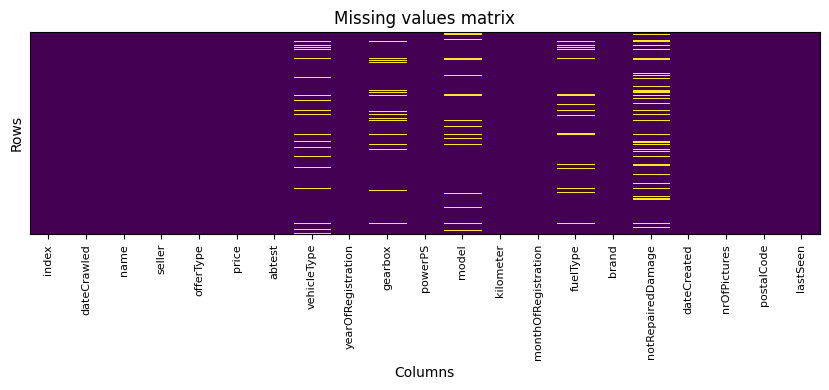

In [11]:
if missing_df.empty:
    display(Markdown("_Пропусков нет или датасет пуст._"))
else:
    display(Markdown("### Таблица пропусков по колонкам"))
    display(missing_df)
    display(Markdown("### Матрица пропусков"))
    plot_missing_matrix(df)

---
### 5. Проблемные колонки

In [12]:
problematic_cols_df = problematic_columns(summary, MIN_MISSING_SHARE)

if problematic_cols_df.empty:
    display(Markdown(f"_Нет колонок с долей пропусков ≥ {MIN_MISSING_SHARE:.0%}._"))
else:
    display(Markdown(f"### Колонки с долей пропусков ≥ {MIN_MISSING_SHARE:.0%}"))
    display(problematic_cols_df)

_Нет колонок с долей пропусков ≥ 50%._

---
### 6. Корреляция числовых признаков

### Корреляционная матрица (Пирсон)

,index,price,yearOfRegistration,powerPS,kilometer,monthOfRegistration,nrOfPictures,postalCode
index,1.000000,-0.000696,-0.000060,0.000769,0.003625,0.000914,nan,0.000038
price,-0.000696,1.000000,-0.000182,0.006850,-0.000635,-0.002826,nan,-0.003164
yearOfRegistration,-0.000060,-0.000182,1.000000,0.000351,-0.055319,-0.011607,nan,-0.001652
powerPS,0.000769,0.006850,0.000351,1.000000,-0.010738,0.044358,nan,0.027113
kilometer,0.003625,-0.000635,-0.055319,-0.010738,1.000000,0.001838,nan,-0.026694
monthOfRegistration,0.000914,-0.002826,-0.011607,0.044358,0.001838,1.000000,nan,0.014963
nrOfPictures,nan,nan,nan,nan,nan,nan,nan,nan
postalCode,0.000038,-0.003164,-0.001652,0.027113,-0.026694,0.014963,nan,1.000000


### Тепловая карта корреляции

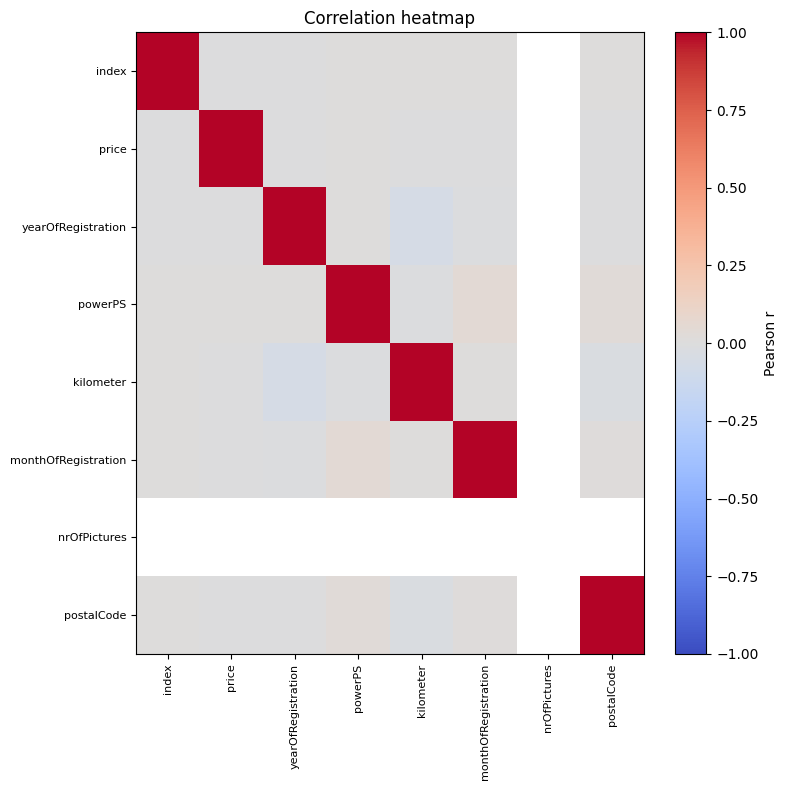

In [13]:
corr_df = correlation_matrix(df)

if corr_df.empty:
    display(Markdown("_Недостаточно числовых колонок для корреляции._"))
else:
    display(Markdown("### Корреляционная матрица (Пирсон)"))
    display(corr_df.style.background_gradient(cmap="coolwarm", vmin=-1, vmax=1))
    display(Markdown("### Тепловая карта корреляции"))
    plot_correlation_heatmap(df)

---
### 7. Категориальные признаки

In [14]:
top_cats = top_categories(df)

if not top_cats:
    display(Markdown("_Категориальные/строковые признаки не найдены._"))
else:
    for col_name, table in top_cats.items():
        display(Markdown(f"### `{col_name}` — топ значений"))
        display(table)

_Категориальные/строковые признаки не найдены._

---
### 8. Гистограммы числовых колонок

In [ ]:
plot_histograms_per_column(df, max_columns=MAX_HIST_COLUMNS)